In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [2]:
df=pd.read_csv('/content/student-mat.csv',sep=';')

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
catcols=df.select_dtypes(include='object')
numcols=df.select_dtypes(include='number')

In [6]:
print(catcols)


    school sex address famsize Pstatus      Mjob      Fjob  reason guardian  \
0       GP   F       U     GT3       A   at_home   teacher  course   mother   
1       GP   F       U     GT3       T   at_home     other  course   father   
2       GP   F       U     LE3       T   at_home     other   other   mother   
3       GP   F       U     GT3       T    health  services    home   mother   
4       GP   F       U     GT3       T     other     other    home   father   
..     ...  ..     ...     ...     ...       ...       ...     ...      ...   
390     MS   M       U     LE3       A  services  services  course    other   
391     MS   M       U     LE3       T  services  services  course   mother   
392     MS   M       R     GT3       T     other     other  course    other   
393     MS   M       R     LE3       T  services     other  course   mother   
394     MS   M       U     LE3       T     other   at_home  course   father   

    schoolsup famsup paid activities nursery higher

In [7]:
print(numcols)

     age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  \
0     18     4     4           2          2         0       4         3   
1     17     1     1           1          2         0       5         3   
2     15     1     1           1          2         3       4         3   
3     15     4     2           1          3         0       3         2   
4     16     3     3           1          2         0       4         3   
..   ...   ...   ...         ...        ...       ...     ...       ...   
390   20     2     2           1          2         2       5         5   
391   17     3     1           2          1         0       2         4   
392   21     1     1           1          1         3       5         5   
393   18     3     2           3          1         0       4         4   
394   19     1     1           1          1         0       3         2   

     goout  Dalc  Walc  health  absences  G1  G2  G3  
0        4     1     1       3         6   5

In [8]:
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder
for i in range(len(catcols.columns)):
  le=LabelEncoder()
  df[catcols.columns[i]]=le.fit_transform(df[catcols.columns[i]])

In [9]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


In [10]:
from sklearn.model_selection import train_test_split
X = df.drop('G3', axis=1)
y = df['G3']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x_train=s.fit_transform(x_train)
x_test=s.fit_transform(x_test)

In [ ]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(1, activation='relu')
])

In [ ]:
model.compile( 
    optimizer='adam',
    loss='mse',
    metrics=['MSE']
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,#Understanding mini-batch gradient descent here
    validation_split=0.2 # 20% of the data is used for validation
)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - MSE: 118.9999 - loss: 118.9999 - val_MSE: 118.8665 - val_loss: 118.8665
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - MSE: 118.7083 - loss: 118.7083 - val_MSE: 118.7242 - val_loss: 118.7242
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - MSE: 118.4545 - loss: 118.4545 - val_MSE: 118.5260 - val_loss: 118.5260
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - MSE: 118.1659 - loss: 118.1659 - val_MSE: 118.3288 - val_loss: 118.3288
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - MSE: 117.8995 - loss: 117.8995 - val_MSE: 118.1316 - val_loss: 118.1316


In [23]:
test_loss, test_accuracy = model.evaluate(x_test, y_test) # Model is tested on unseen images

print(f"\nTest Accuracy: {test_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MSE: 124.3275 - loss: 124.3275

Test Accuracy: 124.3275


In [24]:
predictions = model.predict(x_test)
print("First 5 predictions:")
print(predictions[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
First 5 predictions:
[[0.        ]
 [1.1125959 ]
 [0.30340478]
 [0.        ]
 [1.4979202 ]]


In [25]:
print("Predictions from index 5 to 10:")
print(predictions[5:11])

Predictions from index 5 to 10:
[[0.33252028]
 [0.63614434]
 [0.        ]
 [0.75318503]
 [2.5077348 ]
 [0.78476346]]


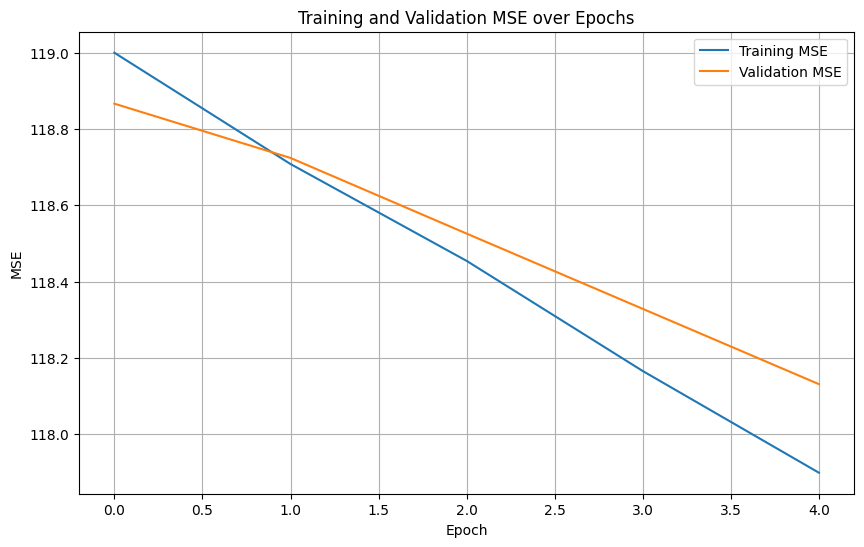

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['MSE'], label='Training MSE')
plt.plot(history.history['val_MSE'], label='Validation MSE')
plt.title('Training and Validation MSE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()